# QCPINN
Luego de tener los modulos corriendo y la carpeta lista para comenzar a realizar pruebas, vamos a exportar elementos de lo que tenemos que son de mayor interés para nosotros.

## 0. Importamos librerias y modulos
Llamamos a los modulos, librerias y componentes necesarios para estudio

In [2]:
# Librerias de interés
import torch
import os
import sys

import pennylane as qml

import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Linea adicional para ubicación de path en los scripts
sys.path.append(os.getcwd())

print(f"Se adiciona al $PATH la variable: {sys.path[-1]}")

Se adiciona al $PATH la variable: /Users/chubbs/Documents/UN/QCPINN/Quan_PINN


In [4]:

# Importe de componentes adicionales de estudio
from src.utils.logger           import Logging
from src.nn.pde                 import wave_operator
from src.utils.plot_prediction  import plt_prediction
from src.data.wave_dataset      import u, r

from src.nn.DVPDESolver         import DVPDESolver
from src.nn.CVPDESolver         import CVPDESolver
from src.nn.ClassicalSolver2    import ClassicalSolver2
from src.data.wave_dataset      import Sampler

import src.trainer.wave_train as wave_train

## 1. Caracterización del modelo
Ahora vamos a entrenar un modelo empleando la misma metodología del articulo para estudiar los cambios que tiene cada uno de los parametros en la ecuación de analisis.

In [52]:
# Cargado de argumentos base para entrenamiento:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mode = "hybrid"
num_qubits = 5
output_dim = 1
input_dim = 2
hidden_dim = 50
num_quantum_layers = 1
cutoff_dim = 20
classic_network = [input_dim, hidden_dim, output_dim]

"""
args = {
    "batch_size": 64,
    "epochs": 1000,
    "lr": 0.005,
    "seed": 1,
    "print_every": 1000,
    "log_path": "./checkpoints/wave",
    "input_dim": input_dim,
    "output_dim": output_dim,
    "num_qubits": num_qubits,
    "hidden_dim": hidden_dim,
    "num_quantum_layers": num_quantum_layers,
    "classic_network": classic_network,
    "q_ansatz": "alternating_layer_tdcnot",  # options: "alternating_layer_tdcnot", "abbas" , farhi , sim_circ_13_half, sim_circ_13 , sim_circ_14_half, sim_circ_14 , sim_circ_15 ,sim_circ_19
    "mode": mode,
    "activation": "null",  # options: "null", "partial_measurement_half" , partial_measurement_x
    "shots": None,  # Analytical gradients enabled
    "problem": "wave",
    "solver": "DV",  # options : "CV", "Classical", "DV"
    "device": DEVICE,
    "method": "None",
    "cutoff_dim": cutoff_dim,  # num_qubits >= cutoff_dim
    "class": "CVNeuralNetwork1",  # options CVNeuralNetwork1, CVNeuralNetwork2, CVNeuralNetwork3
    "encoding": "angle",  # options : "ampiltude" , "angle" for DV , none for others
}
"""

args = {
    "batch_size": 64,
    "epochs": 50,
    "lr": 0.01,
    "seed": 42,
    "print_every": 10,
    "log_path": "./checkpoints/wave",
    "input_dim": input_dim,
    "output_dim": output_dim,
    "num_qubits": num_qubits,
    "hidden_dim": hidden_dim,
    "num_quantum_layers": num_quantum_layers,
    "classic_network": classic_network,
    "q_ansatz": "sim_circ_15",  # options: "alternating_layer_tdcnot", "abbas" , farhi , sim_circ_13_half, sim_circ_13 , sim_circ_14_half, sim_circ_14 , sim_circ_15 ,sim_circ_19
    "mode": mode,
    "activation": "null",  # options: "null", "partial_measurement_half" , partial_measurement_x, tanh (Classical)
    "shots": None,  # Analytical gradients enabled
    "problem": "wave",
    "solver": "DV",  # options : "CV", "Classical", "DV"
    "device": DEVICE,
    "method": "None",
    "cutoff_dim": cutoff_dim,  # num_qubits >= cutoff_dim
    "class": "CVNeuralNetwork2",  # options CVNeuralNetwork1, CVNeuralNetwork2, CVNeuralNetwork3
    "encoding": "None",  # options : "ampiltude" , "angle" for DV , none for others
}

In [53]:
# Inicialización de logger
log_path = args["log_path"]
logger = Logging(log_path)

In [54]:
# Generación de variables de acuerdo a elección de parametros
if args["solver"] == "CV":
    model = CVPDESolver(args, logger, DEVICE)
    model.logger.print("Using CV Solver")
elif args["solver"] == "Classical":
    model = ClassicalSolver2(args, logger, DEVICE)
    model.logger.print("Using Classical Solver")
else:
    model = DVPDESolver(args, logger, DEVICE)
    model.logger.print("Using DV Solver")

model.logger.print(f"The settings used:")
for key, value in args.items():
    model.logger.print(f"{key} : {value}")

INFO:src.utils.logger:Using DV Solver
INFO:src.utils.logger:The settings used:
INFO:src.utils.logger:batch_size : 64
INFO:src.utils.logger:epochs : 50


INFO:src.utils.logger:lr : 0.01
INFO:src.utils.logger:seed : 42
INFO:src.utils.logger:print_every : 10
INFO:src.utils.logger:log_path : ./checkpoints/wave
INFO:src.utils.logger:input_dim : 2
INFO:src.utils.logger:output_dim : 1
INFO:src.utils.logger:num_qubits : 5
INFO:src.utils.logger:hidden_dim : 50
INFO:src.utils.logger:num_quantum_layers : 1
INFO:src.utils.logger:classic_network : [2, 50, 1]
INFO:src.utils.logger:q_ansatz : sim_circ_15
INFO:src.utils.logger:mode : hybrid
INFO:src.utils.logger:activation : null
INFO:src.utils.logger:shots : None
INFO:src.utils.logger:problem : wave
INFO:src.utils.logger:solver : DV
INFO:src.utils.logger:device : cpu
INFO:src.utils.logger:method : None
INFO:src.utils.logger:cutoff_dim : 20
INFO:src.utils.logger:class : CVNeuralNetwork2
INFO:src.utils.logger:encoding : None


In [55]:
# Print total number of parameters
total_params = sum(p.numel() for p in model.parameters())
model.logger.print(f"Total number of parameters: {total_params}")

INFO:src.utils.logger:Total number of parameters: 766


## 2. Entrenamiento controlado de modelo para analisis
Ahora vamos a entrenar un modelo empleando la misma metodología del articulo para estudiar los cambios que tiene cada uno de los parametros en la ecuación de analisis.

In [56]:
# Training of the model
wave_train.train(model)

model.save_state()

model.logger.print("Training completed successfuly!")

INFO:src.utils.logger:The circuit used in the study:


The circuit is saved in ./checkpoints/wave/2025-08-08_13-19-46-220902


INFO:src.utils.logger:It: 0, Loss: 1.422e+01, Loss_res: 5.531e-03,  Loss_bcs: 1.422e+00, Loss_ut_ics: 3.983e-05, lr: 1.000e-02, Time: 8.22e+00
INFO:src.utils.logger:Model state saved to ./checkpoints/wave/2025-08-08_13-19-46-220902/model.pth
INFO:src.utils.logger:Model state saved to ./checkpoints/wave/2025-08-08_13-19-46-220902/model_weights.pth
INFO:src.utils.logger:It: 10, Loss: 3.671e+00, Loss_res: 1.120e-01,  Loss_bcs: 3.647e-01, Loss_ut_ics: 1.221e-01, lr: 1.000e-02, Time: 7.79e+00
INFO:src.utils.logger:Model state saved to ./checkpoints/wave/2025-08-08_13-19-46-220902/model.pth
INFO:src.utils.logger:Model state saved to ./checkpoints/wave/2025-08-08_13-19-46-220902/model_weights.pth
INFO:src.utils.logger:It: 20, Loss: 3.857e+00, Loss_res: 2.196e+00,  Loss_bcs: 3.488e-01, Loss_ut_ics: 1.490e+00, lr: 1.000e-02, Time: 7.96e+00
INFO:src.utils.logger:Model state saved to ./checkpoints/wave/2025-08-08_13-19-46-220902/model.pth
INFO:src.utils.logger:Model state saved to ./checkpoints/w

## 3. Cargado de modelos
Considerado ya modelos entrenados, cargamos los mismos y realizamos pruebas.

In [ ]:
# Generación de dirección
# - 2025-08-06_16-41-27-482030: Clasica
# - 2025-08-06_16-56-24-284684: farhi
# - 2025-08-06_16-55-42-744245: alternating_layer_tdcnot
# - 2025-08-06_17-58-14-334719: sim_circ_19
# - 2025-08-08_12-49-55-685290: sim_circ_5
# - 2025-08-08_13-19-46-220902: sim_circ_15
model_dir = "./checkpoints/wave/2025-08-06_16-41-27-482030"

# Cargado de versiones de los modelos
model_path = os.path.join(model_dir, "model_weights.pth")

# Load the state dictionary into the model
model.load_state_dict(torch.load(model_path))

# Set the model to evaluation mode (important for inference)
model.eval()

ClassicalSolver2(
  (preprocessor): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=50, bias=True)
  )
  (hidden): Sequential(
    (0): Linear(in_features=50, out_features=50, bias=True)
  )
  (postprocessor): Sequential(
    (0): Linear(in_features=50, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=1, bias=True)
  )
  (activation): Tanh()
  (loss_fn): MSELoss()
)

In [28]:
# Generación de dirección
model_dir = "./checkpoints/wave/2025-08-06_17-58-14-334719"

# Cargado de versiones de los modelos
model_path = os.path.join(model_dir, "model.pth")

# Load the state dictionary into the model
state = model.load_state(model_path)

# Set the model to evaluation mode (important for inference)
model.eval()

Model state loaded from ./checkpoints/wave/2025-08-06_17-58-14-334719/model.pth


DVPDESolver(
  (preprocessor): Sequential(
    (0): Linear(in_features=2, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=5, bias=True)
  )
  (postprocessor): Sequential(
    (0): Linear(in_features=5, out_features=50, bias=True)
    (1): Tanh()
    (2): Linear(in_features=50, out_features=1, bias=True)
  )
  (activation): Tanh()
  (quantum_layer): DVQuantumLayer()
  (loss_fn): MSELoss()
)

## 3. Performance del modelo de prueba
Considerando los modelos generados generamos pruebas para test de los mismos

In [57]:
# Print total number of parameters
total_params = sum(p.numel() for p in model.parameters())

model.logger.print(f"Total number of parameters: {total_params}")

INFO:src.utils.logger:Total number of parameters: 766


In [92]:
# Define PINN model
a = torch.tensor(0.7, dtype=torch.float32, device=DEVICE)
c = torch.tensor(2.0, dtype=torch.float32, device=DEVICE)

# Domain boundaries - convert to float32
ics_coords = np.array([[0.0, 0.0], [0.0, 1.0]], dtype=np.float32)
bc1_coords = np.array([[0.0, 0.0], [1.0, 0.0]], dtype=np.float32)
bc2_coords = np.array([[0.0, 1.0], [1.0, 1.0]], dtype=np.float32)
dom_coords = np.array([[0.0, 0.0], [1.0, 1.0]], dtype=np.float32)

# Create initial conditions samplers
ics_sampler = Sampler(2, ics_coords, lambda x: u(x, a, c), device=DEVICE)

# Create boundary conditions samplers
bc1 = Sampler(2, bc1_coords, lambda x: u(x, a, c), device=DEVICE)
bc2 = Sampler(2, bc2_coords, lambda x: u(x, a, c), device=DEVICE)
bcs_sampler = [bc1, bc2]

# Create residual sampler
res_sampler = Sampler(2, dom_coords, lambda x: r(x, a, c), device=DEVICE)
coll_sampler = Sampler(2, dom_coords, lambda x: u(x, a, c), device=DEVICE)

# Create mesh grid with float32
number_of_points = 20
t = np.linspace(dom_coords[0, 0], dom_coords[1, 0], number_of_points, dtype=np.float32)[
    :, None
]
x = np.linspace(dom_coords[0, 1], dom_coords[1, 1], number_of_points, dtype=np.float32)[
    :, None
]
t, x = np.meshgrid(t, x)

# Convert to PyTorch tensor with float32
X_star = (
    torch.hstack(
        (torch.from_numpy(t.flatten()[:, None]), torch.from_numpy(x.flatten()[:, None]))
    )
    .to(DEVICE)
    .to(torch.float32)
)

u_star = u(X_star, a, c)
f_star = r(X_star, a, c)

- Tener presente que para los circuitos de codificación discreta, únicamente es posible emplear los circuitos simbolicos: 
`layered_circuit`, `alternating_layer_tdcnot`, `sim_circ_19`, `farhi`, `sim_circ_15` y  `sim_circ_5`

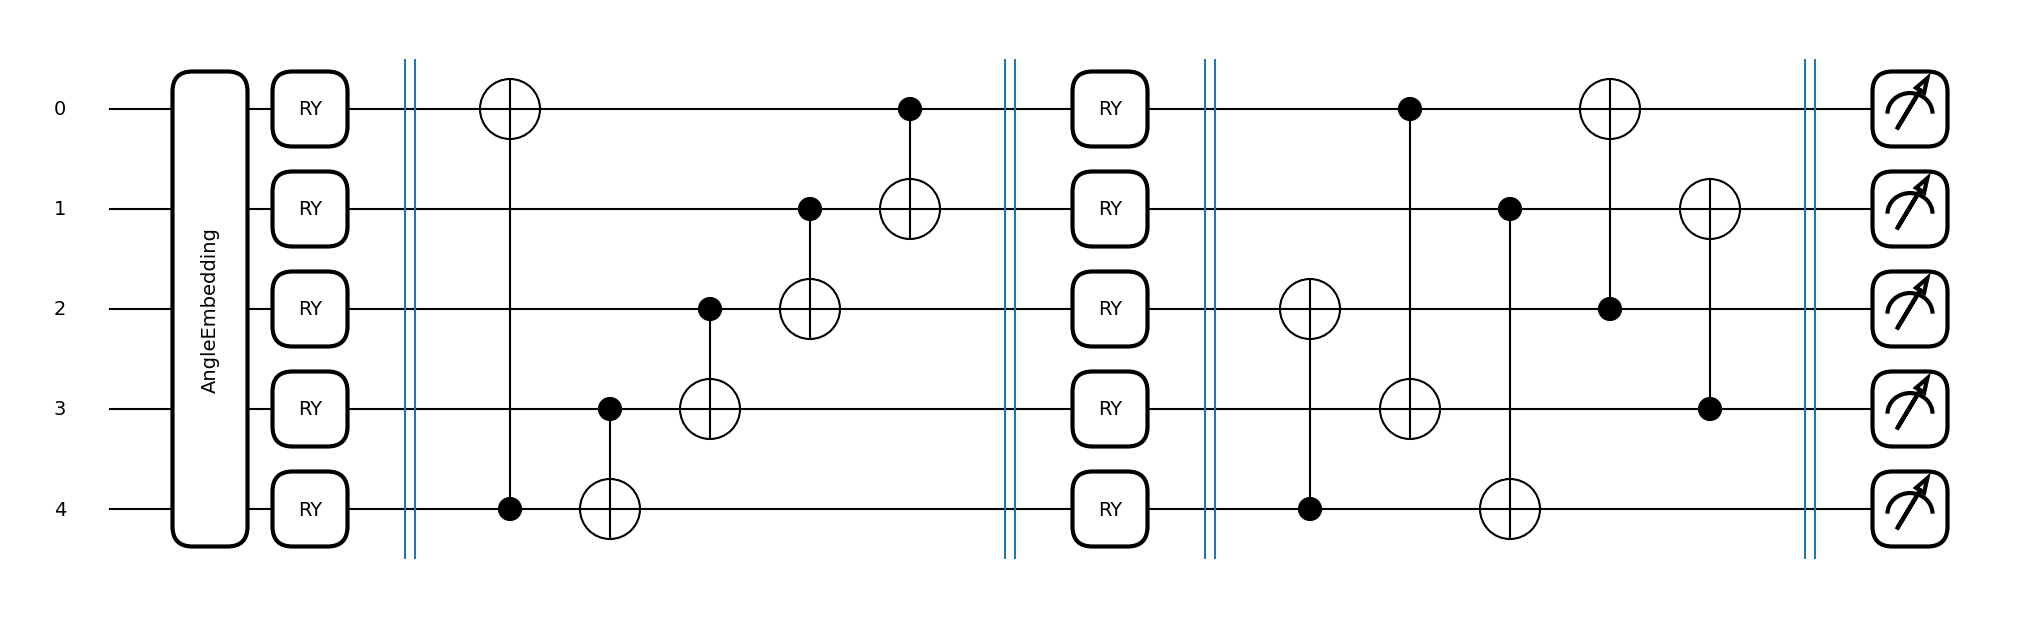

In [94]:
# Circuito de estudio
qml.draw_mpl(model.quantum_layer.circuit)(model.preprocessor(X_star[0, 0:2]));

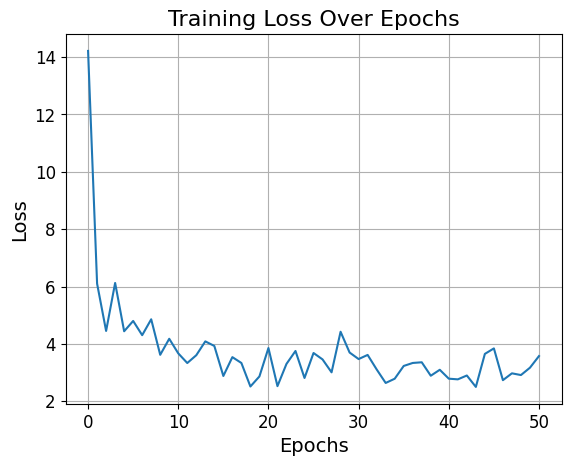

In [60]:
# En caso de entrenamiento se puede generar histogramas de perdida
# en caso contrario, no se generan histogramas.
plt.plot(range(len(model.loss_history)), model.loss_history)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Over Epochs")
plt.grid()

file_path = os.path.join(model.log_path, "loss_history.pdf")
plt.savefig(file_path, bbox_inches="tight")
plt.show()

plt.close(
    "all",
)

In [95]:
# Predictions
u_pred_star, f_pred_star = wave_operator(model, X_star[:, 0:1], X_star[:, 1:2])

u_pred = u_pred_star.cpu().detach().numpy()
f_pred = f_pred_star.cpu().detach().numpy()
u_star = u_star.cpu().detach().numpy()
f_star = f_star.cpu().detach().numpy()
X = X_star.cpu().detach().numpy()

# Relative L2 error
error_u = (
    np.linalg.norm(u_pred - u_star) / np.linalg.norm(u_star) * 100
    if np.linalg.norm(u_star)
    else float("inf")
)
error_f = np.linalg.norm(f_pred - f_star)
logger.print("Relative L2 error_u: {:.2e}".format(error_u))
logger.print("Relative L2 error_f: {:.2e}".format(error_f))

INFO:src.utils.logger:Relative L2 error_u: 1.00e+02
INFO:src.utils.logger:Relative L2 error_f: 2.34e+01


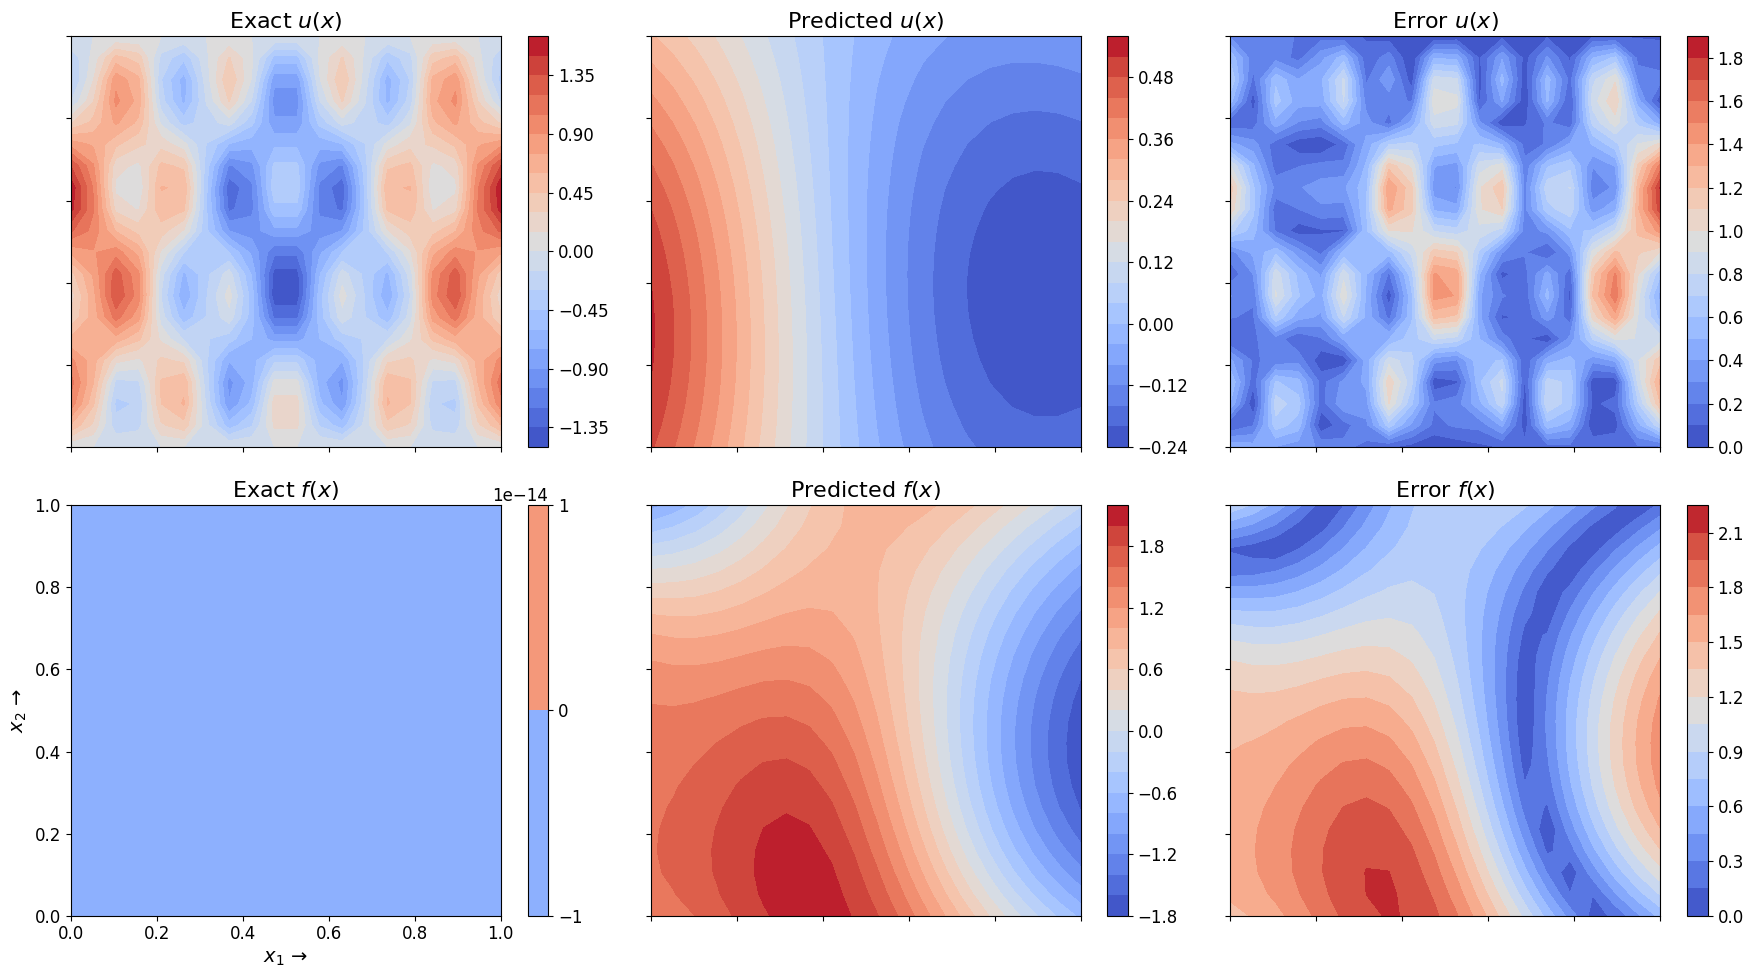

In [96]:
# Plot predictions
plt_prediction(
    logger,
    X,
    u_star,
    u_pred,
    f_star,
    f_pred,
)